<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Подготовка" data-toc-modified-id="Подготовка-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Подготовка</a></span><ul class="toc-item"><li><span><a href="#Загрузка-данных" data-toc-modified-id="Загрузка-данных-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Загрузка данных</a></span></li><li><span><a href="#Предобработка-данных" data-toc-modified-id="Предобработка-данных-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Предобработка данных</a></span></li><li><span><a href="#Предобработка-текста" data-toc-modified-id="Предобработка-текста-1.3"><span class="toc-item-num">1.3&nbsp;&nbsp;</span>Предобработка текста</a></span></li></ul></li><li><span><a href="#Обучение" data-toc-modified-id="Обучение-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Обучение</a></span><ul class="toc-item"><li><span><a href="#Подготовка-данных" data-toc-modified-id="Подготовка-данных-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Подготовка данных</a></span></li><li><span><a href="#Обучение-моделей" data-toc-modified-id="Обучение-моделей-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Обучение моделей</a></span></li><li><span><a href="#Тестирование" data-toc-modified-id="Тестирование-2.3"><span class="toc-item-num">2.3&nbsp;&nbsp;</span>Тестирование</a></span></li></ul></li><li><span><a href="#Выводы" data-toc-modified-id="Выводы-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Выводы</a></span></li><li><span><a href="#Чек-лист-проверки" data-toc-modified-id="Чек-лист-проверки-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Чек-лист проверки</a></span></li></ul></div>

In [1]:
#загружаю библиотеки
!pip install matplotlib seaborn scipy catboost -q
!pip install --upgrade pandas "dask[complete]" -q
!pip install numpy==1.24.3 h5py==3.8.0 spacy==3.5.0 -U -q
!python -m spacy download en_core_web_sm -q

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import re
import sklearn
import seaborn as sns
import nltk
import scipy.stats as st
import random
import spacy


from statsmodels.tsa.seasonal import seasonal_decompose
from matplotlib import pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.experimental import enable_halving_search_cv  
from sklearn.model_selection import train_test_split, RandomizedSearchCV, HalvingGridSearchCV, cross_validate, cross_val_score
from sklearn.metrics import f1_score

[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


C:\Users\Елена\AppData\Roaming\Python\Python310\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Елена\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Елена\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Елена\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


# Проект для «Викишоп»

Интернет-магазин «Викишоп» запускает новый сервис. Теперь пользователи могут редактировать и дополнять описания товаров, как в вики-сообществах. То есть клиенты предлагают свои правки и комментируют изменения других. Магазину нужен инструмент, который будет искать токсичные комментарии и отправлять их на модерацию. 

Обучите модель классифицировать комментарии на позитивные и негативные. В вашем распоряжении набор данных с разметкой о токсичности правок.

Постройте модель со значением метрики качества *F1* не меньше 0.75. 

**Инструкция по выполнению проекта**

1. Загрузите и подготовьте данные.
2. Обучите разные модели. 
3. Сделайте выводы.

Для выполнения проекта применять *BERT* необязательно, но вы можете попробовать.

**Описание данных**

Данные находятся в файле `toxic_comments.csv`. Столбец *text* в нём содержит текст комментария, а *toxic* — целевой признак.

**Цель исследования:** 

Построить модель машинного обучения, которая сможет классифицировать комментарии на позитивные и негативные. 

**Ход исследования:**

1. Подготовка данных: загрузка и изучение общей информации из датасетов, обработка дубликатов и изменение типов данных, исследовательский анализ данных
2. Обучение моделей
3. Выводы

**Общий вывод:** резюмирование полученных результатов, формулировка ключевых выводов и рекомендаций

## Подготовка

### Загрузка данных

In [3]:
# задаю путь к файлам: сначала платформенный путь, затем локальный
platform_path = '/datasets/toxic_comments.csv'
local_path = 'toxic_comments.csv'  

# функция для загрузки данных с обработкой ошибок
def load_data(path):
    try:
        df = pd.read_csv(path)
        print(f"Данные успешно загружены с пути: {path}")
        return df
    except FileNotFoundError:
        print(f"Файл не найден по пути {path}.")
        return None
    except Exception as e:
        print(f"Ошибка при загрузке данных с пути {path}: {str(e)}")
        return None

# сначала пробую загрузить с платформы
df_toxic_comments = load_data(platform_path)

# если загрузка через платформу не удалась, пробую локальный путь
if df_toxic_comments is None:
    df_toxic_comments = load_data(local_path)

Файл не найден по пути /datasets/toxic_comments.csv.
Данные успешно загружены с пути: toxic_comments.csv


In [4]:
display(df_toxic_comments.info()) #вывожу общую информацию о датасете

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159292 entries, 0 to 159291
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  159292 non-null  int64 
 1   text        159292 non-null  object
 2   toxic       159292 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.6+ MB


None

In [5]:
display(df_toxic_comments.head()) #вывожу первые строки
display(df_toxic_comments.tail()) #вывожу последние строки

,Unnamed: 0,text,toxic
0,0,Explanation\nWhy the edits made under my usern...,0
1,1,D'aww! He matches this background colour I'm s...,0
2,2,"Hey man, I'm really not trying to edit war. It...",0
3,3,"""\nMore\nI can't make any real suggestions on ...",0
4,4,"You, sir, are my hero. Any chance you remember...",0


,Unnamed: 0,text,toxic
159287,159446,""":::::And for the second time of asking, when ...",0
159288,159447,You should be ashamed of yourself \n\nThat is ...,0
159289,159448,"Spitzer \n\nUmm, theres no actual article for ...",0
159290,159449,And it looks like it was actually you who put ...,0
159291,159450,"""\nAnd ... I really don't think you understand...",0


**Вывод:**
В данных df_toxic_comments 159292 строки. Пропусков не обнаружено. Тип столбцов указаны верно

### Предобработка данных

**Поиск дубликатов**

In [6]:
#исследую данные на наличие явных дубликатов
print('Количество явных дубликатов в "df_toxic_comments" = ', df_toxic_comments.duplicated().sum())

Количество явных дубликатов в "df_toxic_comments" =  0


In [7]:
#проверяю на неявные дубликаты
print('Количество неявных дубликатов в "df_toxic_comments" = ', df_toxic_comments.duplicated(subset=['text', 'toxic']).sum())

Количество неявных дубликатов в "df_toxic_comments" =  0


**Анализ уникальных значений**

In [8]:
print(f'Уникальные значения для toxic:{df_toxic_comments["toxic"].unique()}')

Уникальные значения для toxic:[0 1]


**Удаление столбца Unnamed: 0**

Поскольку столбец Unnamed: 0 не является необходимым для последующего анализа, удалю его

In [9]:
df_toxic_comments = df_toxic_comments[['text', 'toxic']]
display(df_toxic_comments.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159292 entries, 0 to 159291
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    159292 non-null  object
 1   toxic   159292 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ MB


None

**Вывод:**
Выполнена предобработка данных. Удален столбец Unnamed: 0

### Предобработка текста

**Токенизация и лемматизация**

In [11]:
nlp = spacy.load('en_core_web_sm')

def lemmatize_text(text):
    doc = nlp(text)  # Применяем spaCy к тексту
    lemm_text = " ".join([token.lemma_ for token in doc if not token.is_stop and not token.is_punct])
    lemm_text = re.sub(r'\s+', ' ', lemm_text).strip()  # Удаляем лишние пробелы и символы новой строки
    return lemm_text

tqdm.pandas(desc="Lemmatizing Text")
df_toxic_comments['lemm_text'] = df_toxic_comments['text'].progress_apply(lemmatize_text)

display(df_toxic_comments.head())

Lemmatizing Text: 100%|████████████████████████████████████████████████████████| 159292/159292 [49:31<00:00, 53.61it/s]


,text,toxic,lemm_text
0,Explanation\nWhy the edits made under my usern...,0,Explanation edit username Hardcore Metallica F...
1,D'aww! He matches this background colour I'm s...,0,D'aww match background colour seemingly stick ...
2,"Hey man, I'm really not trying to edit war. It...",0,hey man try edit war guy constantly remove rel...
3,"""\nMore\nI can't make any real suggestions on ...",0,real suggestion improvement wonder section sta...
4,"You, sir, are my hero. Any chance you remember...",0,sir hero chance remember page


In [12]:
df_toxic_comments = df_toxic_comments[['lemm_text','toxic']]
display(df_toxic_comments.head())

,lemm_text,toxic
0,Explanation edit username Hardcore Metallica F...,0
1,D'aww match background colour seemingly stick ...,0
2,hey man try edit war guy constantly remove rel...,0
3,real suggestion improvement wonder section sta...,0
4,sir hero chance remember page,0


**Вывод**

Проведена лемматизация текста

## Обучение

### Подготовка данных

Нужно провести стратификацию данных при их подготовке

In [13]:
RANDOM_STATE=42

X = df_toxic_comments.drop(['toxic'], axis=1)
y = df_toxic_comments['toxic']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.25, 
    random_state = RANDOM_STATE,
    stratify = y)

In [14]:
print("Размерности выборок:")
print("Тренировочная выборка (X_train):", X_train.shape)
print("Тестовая выборка (X_test):", X_test.shape)

Размерности выборок:
Тренировочная выборка (X_train): (119469, 1)
Тестовая выборка (X_test): (39823, 1)


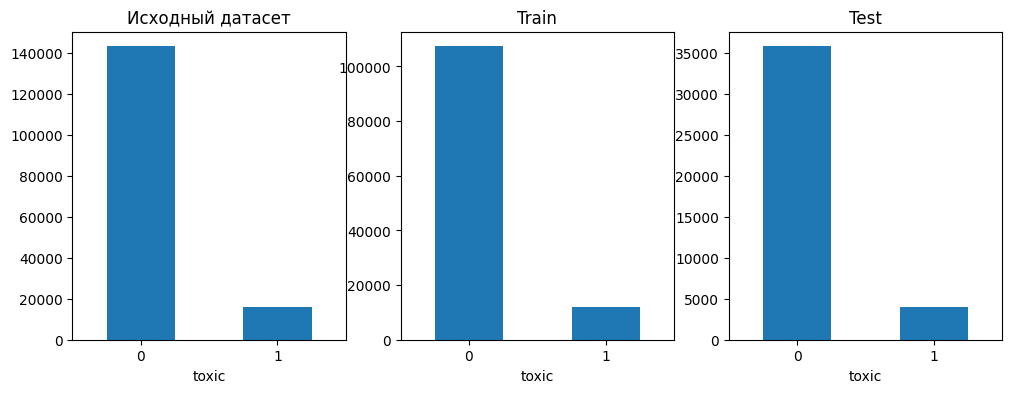

In [15]:
# визуализация баланса целевого признака в выборках
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

y.value_counts().plot(kind='bar', ax=ax[0], rot=0)
ax[0].set_title("Исходный датасет")
y_train.value_counts().plot(kind='bar', ax=ax[1], rot=0)
ax[1].set_title("Train")
y_test.value_counts().plot(kind='bar', ax=ax[2], rot=0)
ax[2].set_title("Test")

plt.show()

In [16]:
# загружаю стоп-слова
stopwords_list = stopwords.words('english')

# создаю TfidfVectorizer и передаю список стоп-слов
count_tf_idf = TfidfVectorizer(stop_words=stopwords_list)

In [17]:
tf_idf_train = count_tf_idf.fit_transform(X_train['lemm_text'])
tf_idf_test = count_tf_idf.transform(X_test['lemm_text'])

In [18]:
print("Размерности выборок:")
print("Тренировочная выборка (tf_idf_train):", tf_idf_train.shape)
print("Тестовая выборка (tf_idf_test):", tf_idf_test.shape)

Размерности выборок:
Тренировочная выборка (tf_idf_train): (119469, 148129)
Тестовая выборка (tf_idf_test): (39823, 148129)


**Вывод**

Проведена стратификация данных. Выборка разделена на тренировочную и тестовую для проверки качества предсказания моделей. Созданы векторизации теста

### Обучение моделей

Для обучения модели выберу следующие классификаторы:

- LogisticRegression
- DecisionTreeClassifier

In [19]:
def train_model(model, X, y, results_df, param_grid=None):
    if param_grid:  # Если есть сетка гиперпараметров
        halving_grid_cv = HalvingGridSearchCV(
            model, 
            param_grid, 
            factor=2,  # Уменьшает количество моделей вдвое на каждом этапе
            cv=3, 
            n_jobs=-1,
            scoring='f1',  # Изменяем метрику на F1
            return_train_score=True
        )
        halving_grid_cv.fit(X, y)
        best_model = halving_grid_cv.best_estimator_
        cross_val_f1 = halving_grid_cv.best_score_  # Получаем лучший F1 с GridSearch
    else:  # Если гиперпараметры не подбираются
        cv_results = cross_validate(model, X, y, cv=3,
                                    scoring='f1', return_train_score=False,
                                    n_jobs=-1)
        model.fit(X, y)
        best_model = model
        cross_val_f1 = np.mean(cv_results['test_score'])  # Среднее значение F1 по кросс-валидации
    # Обучаем модель для предсказаний
    predictions = best_model.predict(X)
    result_row = {
        'Model': best_model.__class__.__name__,
        'F1 Score': cross_val_f1,  # Записываем F1 
    }

    results_df = pd.concat([results_df, pd.DataFrame([result_row])], ignore_index=True)

    print('Гиперпараметры модели:\n', best_model.get_params())
    print('F1 Score модели равен:', cross_val_f1)

    return cross_val_f1, best_model, results_df

In [20]:
results_df = pd.DataFrame(columns=['Model', 'F1 Score'])

**LogisticRegression**

In [21]:
logistic_model = LogisticRegression(max_iter=200)
#logistic_param_grid = {'C': [0.1, 1, 10], 'solver': ['liblinear', 'saga']}
logistic_param_grid = {
    'C': [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
    'solver': ['liblinear', 'saga'],
    'penalty': ['l1', 'l2']
}
cross_val_f1, best_model_lg, results_df = train_model(logistic_model, tf_idf_train, y_train, results_df, logistic_param_grid)

C:\Users\Елена\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Temp\ipykernel_31184\3503436194.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, pd.DataFrame([result_row])], ignore_index=True)


Гиперпараметры модели:
 {'C': 9, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 200, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l1', 'random_state': None, 'solver': 'saga', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
F1 Score модели равен: 0.770279582949125


**DecisionTreeClassifier**

In [22]:
tree_model = DecisionTreeClassifier(random_state=42)
tree_param_grid = {'max_depth': [None, 10, 20, 30], 'min_samples_split': [2, 5, 10]}
cross_val_f1, best_model_dt, results_df = train_model(tree_model, tf_idf_train, y_train, results_df, tree_param_grid)

Гиперпараметры модели:
 {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 10, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}
F1 Score модели равен: 0.7189364169853851


In [23]:
display(results_df)

,Model,F1 Score
0,LogisticRegression,0.770280
1,DecisionTreeClassifier,0.718936


**Вывод**

Если ориентироваться на качество предсказания, то лучшей моделью следует считать LogisticRegression с гиперпараметрами {'C': 9, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 200, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l1', 'random_state': None, 'solver': 'saga', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

### Тестирование

In [24]:
# Предсказание на тестовых данных
predictions = best_model_lg.predict(tf_idf_test)
f1 = f1_score(y_test, predictions)

print(f'F1 Score = {f1}')


F1 Score = 0.7740128068303095


**Вывод**

На тестовой выборке модель показывает хорошую метрику F1 = 0.7740128068303095

## Выводы

В ходе данного исследования было необходимо построить модель машинного обучения, которая сможет классифицировать комментарии на позитивные и негативные.

Работа состояла из нескольких этапов:
1. Подготовка данных: 
- Выполнена предобработка данных. Удален столбец Unnamed: 0;
- Проведена лемматизация текста.

2. Обучение моделей
- Проведена стратификация данных. Выборка разделена на тренировочную и тестовую для проверки качества предсказания моделей. Созданы векторизации теста;
- Для обучения модели выберу следующие классификаторы:

  - LogisticRegression
  - DecisionTreeClassifier

- Если ориентироваться на качество предсказания, то лучшей моделью следует считать LogisticRegression с гиперпараметрами {'C': 9, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 200, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l1', 'random_state': None, 'solver': 'saga', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

- На тестовой выборке обученная модель LogisticRegression показывает хорошую метрику F1 = 0.7740128068303095